In [1]:
%load_ext autoreload 
%autoreload 2

import os, sys
project_root = os.path.abspath(os.path.join(os.getcwd(), "../../.."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
print(project_root)

import math
import numpy as np
import pandas as pd
from numpy import array
from numpy import array, arange, abs as np_abs
from numpy.fft import rfft, rfftfreq
from math import sin, pi
from scipy import signal
import matplotlib.pyplot as plt
import plotly.graph_objects as go

import importlib
import model as md
import view as vw

importlib.reload(md)
importlib.reload(vw)

c:\Users\Артем\Desktop\Вуз\Аспирантура\Диссертация\Алгоритм\Relaxation_frequency_phase_algorithm


<module 'view' from 'c:\\Users\\Артем\\Desktop\\Вуз\\Аспирантура\\Диссертация\\Алгоритм\\Relaxation_frequency_phase_algorithm\\view\\__init__.py'>


📁 Обработка папки: c:\Users\Артем\Desktop\Вуз\Аспирантура\Диссертация\Алгоритм\Relaxation_frequency_phase_algorithm\data\bio\2
RTB2004_CHAN1.CSV → phase = 51.29338606501893
RTB2004_CHAN1(1).CSV → phase = 48.941478765534036
RTB2004_CHAN1(2).CSV → phase = 46.874305013738216
RTB2004_CHAN1(3).CSV → phase = 45.38718248427149
RTB2004_CHAN1(4).CSV → phase = 45.717406700839746
RTB2004_CHAN1(5).CSV → phase = 40.5178775905258
RTB2004_CHAN1(6).CSV → phase = 35.5351071716093


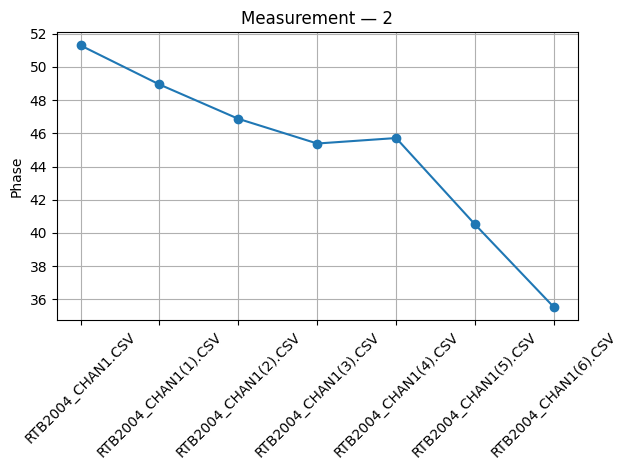


📁 Обработка папки: c:\Users\Артем\Desktop\Вуз\Аспирантура\Диссертация\Алгоритм\Relaxation_frequency_phase_algorithm\data\bio\3
RTB2004_CHAN1.CSV → phase = 50.98360022804642
RTB2004_CHAN1(1).CSV → phase = 48.12654063757469
RTB2004_CHAN1(2).CSV → phase = 43.47161842078629
RTB2004_CHAN1(3).CSV → phase = 40.58857657455774
RTB2004_CHAN1(4).CSV → phase = 36.705260090113974
RTB2004_CHAN1(5).CSV → phase = 45.58136652945806
RTB2004_CHAN1(6).CSV → phase = 45.55344854306388
RTB2004_CHAN1(7).CSV → phase = 45.63279695044355


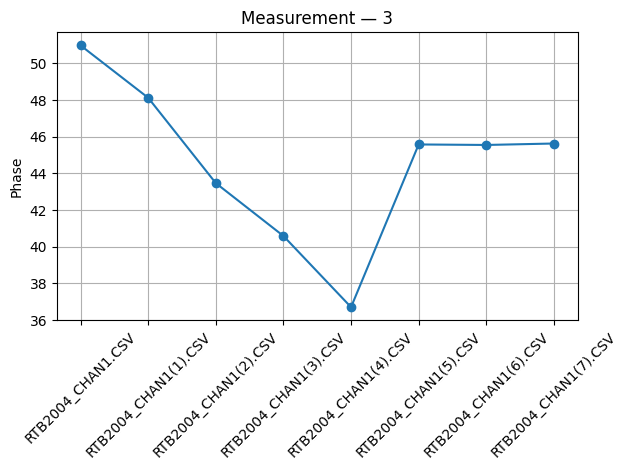


📁 Обработка папки: c:\Users\Артем\Desktop\Вуз\Аспирантура\Диссертация\Алгоритм\Relaxation_frequency_phase_algorithm\data\bio\4
RTB2004_CHAN1.CSV → phase = 46.94706924518697
RTB2004_CHAN1(1).CSV → phase = 45.42037819243812
RTB2004_CHAN1(2).CSV → phase = 43.40509315748033
RTB2004_CHAN1(3).CSV → phase = 35.90349324206651
RTB2004_CHAN1(4).CSV → phase = 34.77462650823968
RTB2004_CHAN1(5).CSV → phase = 33.55725586494992
RTB2004_CHAN1(6).CSV → phase = 32.66781260559482
RTB2004_CHAN1(7).CSV → phase = 33.65505456295224
RTB2004_CHAN1(8).CSV → phase = 33.60313797593387


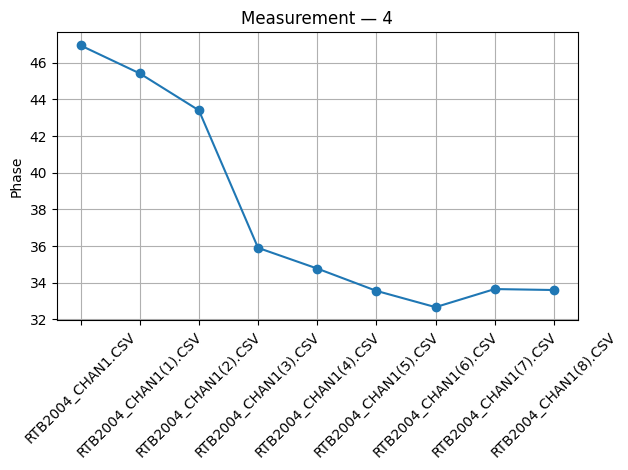


📁 Обработка папки: c:\Users\Артем\Desktop\Вуз\Аспирантура\Диссертация\Алгоритм\Relaxation_frequency_phase_algorithm\data\bio\5
RTB2004_CHAN1.CSV → phase = 50.2370119076392
RTB2004_CHAN1(1).CSV → phase = 48.1723956083931
RTB2004_CHAN1(2).CSV → phase = 46.63602160308225
RTB2004_CHAN1(3).CSV → phase = 42.340988961819775
RTB2004_CHAN1(4).CSV → phase = 41.98833543344538
RTB2004_CHAN1(5).CSV → phase = 40.11565849677166
RTB2004_CHAN1(6).CSV → phase = 39.586636725875536
RTB2004_CHAN1(7).CSV → phase = 37.736047470384705
RTB2004_CHAN1(8).CSV → phase = 36.735978011183875
RTB2004_CHAN1(9).CSV → phase = 34.206771192155465


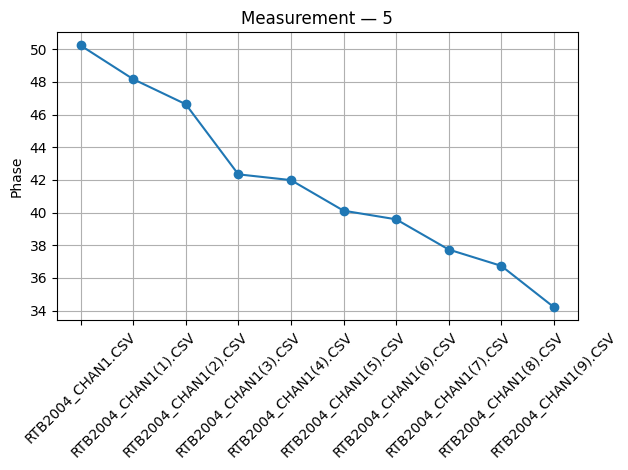

In [2]:
import glob
import re

def extract_index(filename):
    """
    CHAN1.csv -> 0
    CHAN1(1).csv -> 1
    CHAN1(2).csv -> 2
    """
    match = re.search(r"\((\d+)\)", filename)
    if match:
        return int(match.group(1))
    return 0  # базовый файл — первый


def sort_files(file_list):
    return sorted(file_list, key=lambda x: extract_index(os.path.basename(x)))

# --- корневая папка ---
root_dir = os.path.join(project_root, "data", "bio")

# --- обходим ВСЕ подпапки ---
for subdir, dirs, files in os.walk(root_dir):

    chan1_files = glob.glob(os.path.join(subdir, "RTB2004_CHAN1*.csv"))
    chan2_files = glob.glob(os.path.join(subdir, "RTB2004_CHAN2*.csv"))

    if not chan1_files or not chan2_files:
        continue  # пропускаем пустые папки

    # правильная сортировка
    chan1_files = sort_files(chan1_files)
    chan2_files = sort_files(chan2_files)

    phases = []
    labels = []

    print(f"\n📁 Обработка папки: {subdir}")

    for f1, f2 in zip(chan1_files, chan2_files):

        t, U = md.make_real_data_list(f1)
        t, I = md.make_real_data_list(f2)

        F, V = md.get_spectrum3(t, U)
        F_peak_calc = F[np.argmax(V)]

        t_f, U_f = md.filter_butter_bandpass(t, U, F_peak_calc, 200e3, 2)
        t_f, I_f = md.filter_butter_bandpass(t, I, F_peak_calc, 200e3, 2)

        phase = md.get_phase_FFT(t_f, I_f, U_f, F_peak_calc)

        phases.append(phase)
        labels.append(os.path.basename(f1))

        print(f"{os.path.basename(f1)} → phase = {phase}")

    # --- график для каждой папки ---
    plt.figure()
    plt.plot(phases, marker='o')

    plt.xticks(range(len(labels)), labels, rotation=45)
    plt.ylabel("Phase")
    plt.title(f"Measurement — {os.path.basename(subdir)}")
    plt.grid()
    plt.tight_layout()

    plt.show()